In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os

from matplotlib import font_manager as fm
fpath = "Microsoft Aptos Fonts/Aptos.ttf"
prop = fm.FontProperties(fname=fpath)



In [6]:
school_df = pd.read_excel("data/TESDA 2024 EGAC.xlsx")
school_III_IV_df = school_df[school_df['Qualification'].str.contains(r"NC III|NC IV")]
school_df['Graduates'].sum()

np.int64(674087)

In [8]:
school_df['Provider Name'].nunique()

3426

In [6]:
with open('data/nc_sectors.json', 'r') as f:
    tesda_sectors = json.load(f)

In [25]:
(sectors / sectors.sum()).sort_values()

Sector
Personal Care, Social, & Domestic Work           0.005074
Agriculture & Agri-Tech                          0.022517
Construction & Special Trades                    0.027386
Precision Manufacturing                          0.047104
Automotive, Transportation, & Heavy Equipment    0.068594
ICT & Electronics                                0.125175
Healthcare                                       0.239138
Hospitality, Tourism, & Food Service             0.465013
Other Occupations                                     NaN
Name: Graduates, dtype: float64

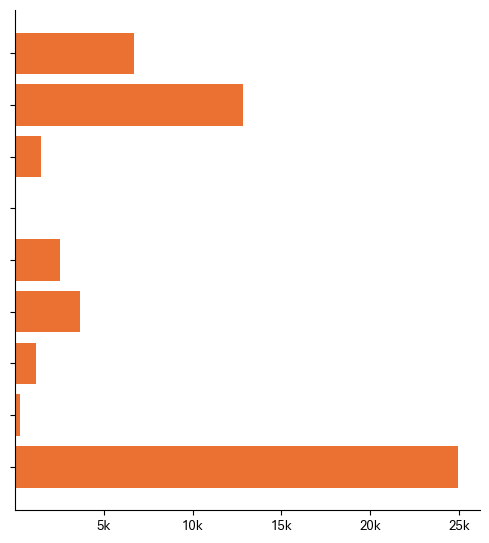

In [21]:
# Your desired order
sector_order = [
    'ICT & Electronics', 
    'Healthcare', 
    'Construction & Special Trades', 
    'Other Occupations', 
    'Precision Manufacturing', 
    'Automotive, Transportation, & Heavy Equipment', 
    'Agriculture & Agri-Tech', 
    'Personal Care, Social, & Domestic Work', 
    'Hospitality, Tourism, & Food Service'
]

school_III_IV_df = school_III_IV_df.copy()
school_III_IV_df.loc[:,'Sector'] = school_III_IV_df['Qualification'].map(tesda_sectors)

# Make 'Sector' a categorical with this order
school_III_IV_df.loc[:, 'Sector'] = pd.Categorical(
    school_III_IV_df['Sector'], 
    categories=sector_order, 
    ordered=True
)

sectors = school_III_IV_df.groupby('Sector', observed=True)['Graduates'].sum().sort_values(ascending=False)
sectors = sectors.reindex(sector_order[::-1])

# Plot
# Custom x-ticks (in graduates)
xticks = [5000, 10000, 15000, 20000, 25000]

fig, ax = plt.subplots(figsize=(6,6.5))
bars = ax.barh(sectors.index, sectors.values, color='#EA7131')

# Hide y-axis labels
ax.set_yticklabels([])

# Set custom x-ticks and labels with Aptos
ax.set_xticks(xticks)
ax.set_xticklabels([f"{x//1000}k" for x in xticks], fontproperties=prop, fontsize=10)

# Clean up spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()

In [63]:
school_III_IV_df['Graduates'].sum() / school_df['Graduates'].sum()

np.float64(0.0795223761917972)

In [66]:
school_III_IV_df.groupby('Qualification')['Graduates'].sum().sort_values(ascending=False)

Qualification
Events Management Services NC III                 23846
Bookkeeping NC III                                12641
Programming (Java) NC III                          3868
Driving (Passenger Bus/Straight Truck) NC III      3264
Visual Graphic Design NC III                       2539
Shielded Metal Arc Welding (SMAW) NC III           1777
Electrical Installation and Maintenance NC III     1389
Agricultural Crops Production NC III                970
Ships' Catering (Ships' Cooks) NC III               811
Mechatronics Servicing NC III                       467
Housekeeping NC III                                 272
Driving (Articulated Vehicle) NC III                264
Shielded Metal Arc Welding (SMAW) NC IV             167
2D Animation NC III                                 155
Pharmacy Services NC III                            140
Commercial Cooking NC III                           133
Agroentrepreneurship NC III                         120
Horticulture NC III               